
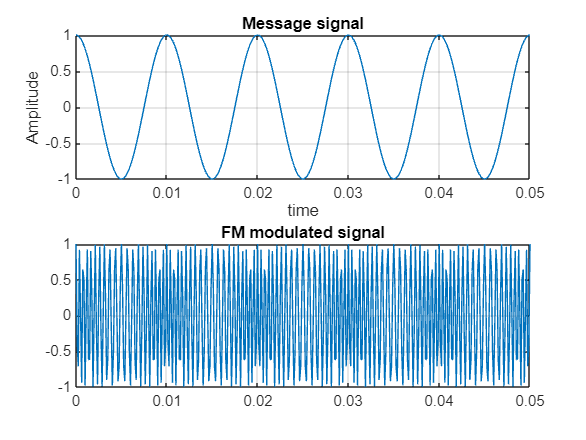

In [1]:
clc;
clear;

fs = 8000;
t = 0.0: 1/fs : 0.05;

Am = 1;
fm = 100;

fc = 2000;
Ac = 1;

Beta = 5;

% Message signal
m = Am*cos(2*pi*fm*t);

% FM signal
Sfm = Ac*cos(2*pi*fc*t + Beta*sin(2*pi*fm*t));

subplot(2, 1, 1)
plot(t, m)
title("Message signal");
xlabel("time");
ylabel("Amplitude");
grid on;

subplot(2, 1, 2)
plot(t, Sfm)
title("FM modulated signal");
grid on;


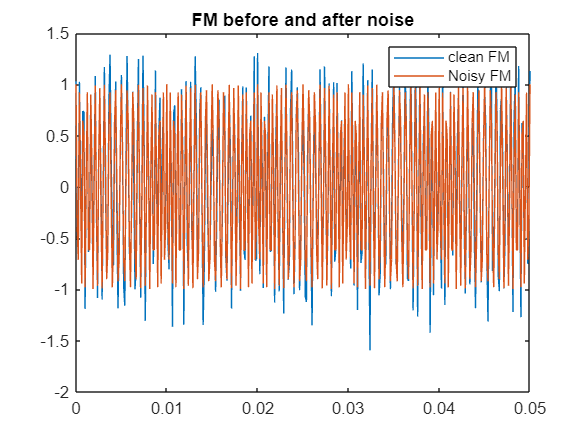

In [2]:
SNR = 10;
noise_sig = awgn(Sfm, SNR, 'measured');

figure;
plot(t, noise_sig);
hold on;
plot(t, Sfm);
legend('clean FM', 'Noisy FM');
title("FM before and after noise");


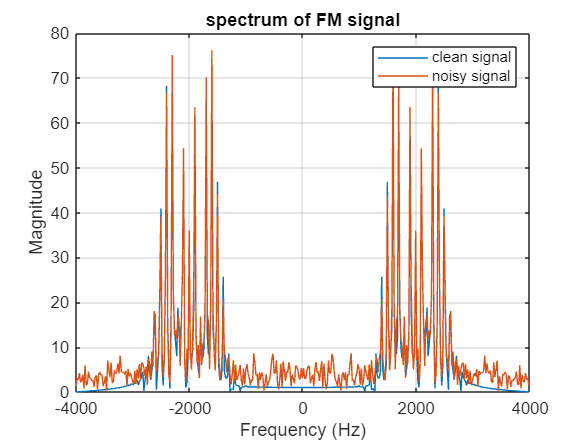

In [3]:
N = length(t);
f = (-N/2: N/2-1)*(fs/N);
s = fftshift(abs(fft(Sfm)));
n = fftshift(abs(fft(noise_sig)));

figure;
plot(f, s); hold on;
plot(f, n);
grid on;
legend('clean signal', 'noisy signal')
title("spectrum of FM signal");
xlabel('Frequency (Hz)');
ylabel('Magnitude');


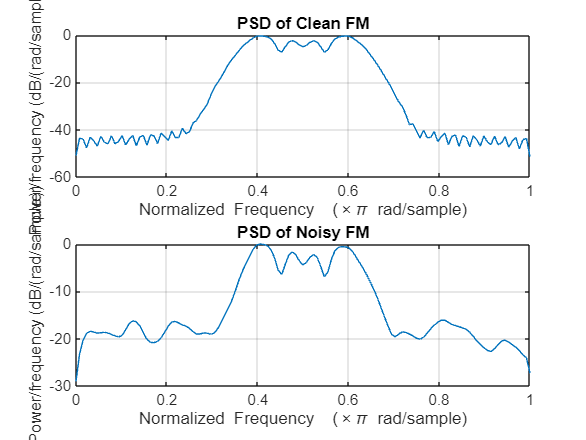

In [4]:
%% Power Spectral Density
figure;
figure('Name','PSD Comparison')

subplot(2,1,1)

pwelch(Sfm)

title('PSD of Clean FM')

subplot(2,1,2)

pwelch(noise_sig)

title('PSD of Noisy FM')


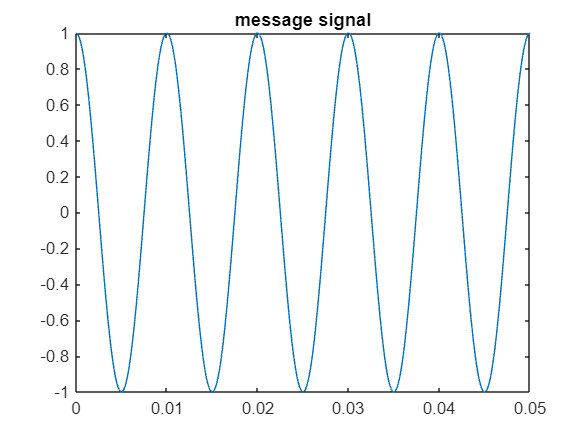

In [5]:
f_low = 1400;
f_high = 2600;

% Filter the noisy signal to remove out-of-band noise
filtered_sig = bandpass(noise_sig, [f_low f_high], fs);

% 3. Demodulate the FILTERED signal instead of the raw noisy signal
demod = fmdemod(filtered_sig, fc, fs, 500);

figure;
plot(t, m)
title("message signal");


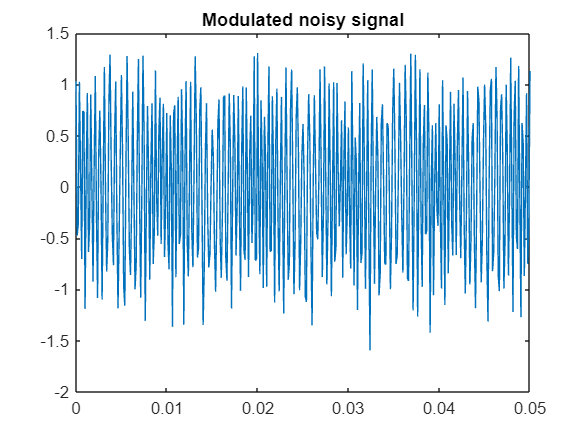

In [6]:

plot(t, noise_sig)
title("Modulated noisy signal")


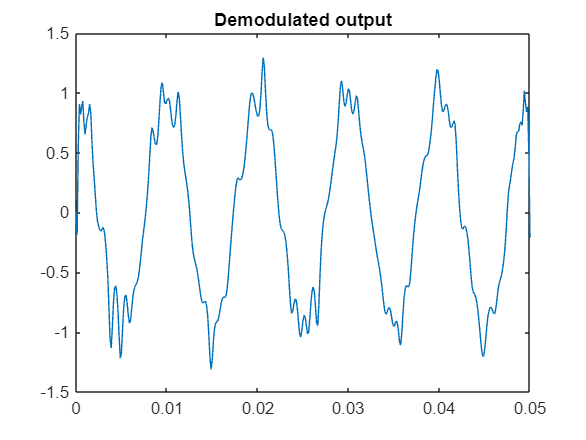

In [7]:

plot(t, demod)
title("Demodulated output");


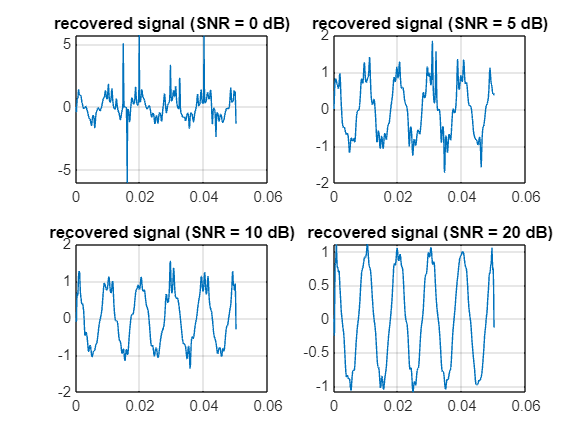

In [8]:
%% Effect of Different SNR Values
f_low = 1400;
f_high = 2600;

snr_values = [0 5 10 20];

figure('Name','SNR Comparison')

for i = 1:length(snr_values)

    r = awgn(Sfm,snr_values(i),'measured');

    % Filter the noisy signal to remove out-of-band noise
    filtered_sig = bandpass(r, [f_low f_high], fs);

    % 3. Demodulate the FILTERED signal instead of the raw noisy signal
    demod = fmdemod(filtered_sig, fc, fs, 500);

    subplot(2,2,i)

    plot(t,demod)

    title(['recovered signal (SNR = ',num2str(snr_values(i)),' dB)'])

    grid on

end




!!!EndOutputRegion!!!